## Heston Stochastic Volatility Model Implementation

Reusable Heston logic lives in `src/heston`. This notebook checks pricing behavior, prepares the calibration dataset, runs the Heston calibration, and displays fit diagnostics.


In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.black_scholes import bs_price, put_call_parity_rhs
from src.heston.calibration import (
    evaluate_heston_fit,
    estimate_initial_params,
    heston_bounds,
    prepare_calibration_data,
    run_calibration,
    summarize_calibration_errors,
    summarize_errors_by_expiry,
    summarize_errors_by_moneyness_bucket,
    summarize_errors_by_option_type,
)
from src.heston.characteristic import heston_char_func
from src.heston.pricing import default_phi_grid, heston_price
from src.market_data import ENRICHED_OPTIONS_PATH
from src.types import HestonParams

### Characteristic Function and Pricing Checks

In [11]:
karlsson_params = HestonParams(v0=0.16, kappa=10.0, theta=0.16, sigma_v=0.10, rho=-0.80)
S, T, r, q = 100.0, 1.0, 0.05, 0.0

char_rows = []
for phi in [0.0, 1.0, 5.0, 25.0, 100.0]:
    for j in [1, 2]:
        value = heston_char_func(phi, S, T, r, karlsson_params, j=j, q=q)
        char_rows.append({"phi": phi, "j": j, "real": value.real, "imag": value.imag, "modulus": abs(value)})

display(pd.DataFrame(char_rows))

,phi,j,real,imag,modulus
0,0.0,1,1.000000e+00,0.000000e+00,1.000000e+00
1,0.0,2,1.000000e+00,0.000000e+00,1.000000e+00
2,1.0,1,2.104141e-02,-9.239332e-01,9.241728e-01
3,1.0,2,-1.256663e-01,-9.139900e-01,9.225887e-01
4,5.0,1,2.514244e-02,-1.374453e-01,1.397260e-01
5,5.0,2,-7.706715e-02,-1.094809e-01,1.338858e-01
6,25.0,1,1.817339e-21,2.309898e-21,2.939106e-21
7,25.0,2,-1.044619e-21,-4.151722e-22,1.124099e-21
8,100.0,1,-1.481093e-230,3.247892e-231,1.516286e-230
9,100.0,2,6.878147e-234,2.124467e-233,2.233036e-233


In [12]:
benchmark_params = HestonParams(v0=0.0175, kappa=1.5768, theta=0.0398, sigma_v=0.5751, rho=-0.5711)
benchmark_price = heston_price(100.0, 100.0, 1.0, 0.0, benchmark_params, option_type="call", q=0.0)

sigma_bs = 0.20
bs_limit_params = HestonParams(v0=sigma_bs**2, kappa=5.0, theta=sigma_bs**2, sigma_v=1e-6, rho=0.0)
bs_limit_price = heston_price(100.0, 100.0, 1.0, 0.05, bs_limit_params, option_type="call", q=0.0)
bs_reference = bs_price(100.0, 100.0, 1.0, 0.05, sigma_bs, option_type="call", q=0.0)

call = heston_price(S, 100.0, T, r, karlsson_params, option_type="call", q=0.012)
put = heston_price(S, 100.0, T, r, karlsson_params, option_type="put", q=0.012)
parity_error = call - put - put_call_parity_rhs(S, 100.0, T, r, q=0.012)

checks = pd.DataFrame(
    [
        {"check": "Fang-Oosterlee benchmark", "value": benchmark_price, "reference": 5.7854, "abs_error": abs(benchmark_price - 5.7854)},
        {"check": "Black-Scholes limit", "value": bs_limit_price, "reference": bs_reference, "abs_error": abs(bs_limit_price - bs_reference)},
        {"check": "Put-call parity", "value": parity_error, "reference": 0.0, "abs_error": abs(parity_error)},
    ]
)
display(checks)

,check,value,reference,abs_error
0,Fang-Oosterlee benchmark,5.785155,5.785400,0.000245
1,Black-Scholes limit,10.450621,10.450584,0.000037
2,Put-call parity,0.000000,0.000000,0.000000


### Calibration Dataset

In [13]:
if not ENRICHED_OPTIONS_PATH.exists():
    raise FileNotFoundError("Run notebook/01_data_acquisition.ipynb before this notebook.")

options = pd.read_csv(ENRICHED_OPTIONS_PATH)

calib = prepare_calibration_data(
    options,
    selection="otm",
    moneyness_range=(0.85, 1.15),
    min_price=0.50,
    min_open_interest=10,
    min_volume=0,
    max_relative_spread=0.15,
    t_bounds=(14 / 365, 1.0),
    iv_bounds=(0.05, 1.00),
    delta_abs_bounds=(0.05, 0.40),
    require_positive_bid=True,
    weight_scheme="expiry_option_type",
)

if calib.empty:
    raise ValueError("Calibration dataset is empty after quality filters.")

calib_summary = pd.DataFrame(
    [
        {"metric": "full_rows", "value": len(options)},
        {"metric": "calibration_rows", "value": len(calib)},
        {"metric": "expiries", "value": calib["expiry"].nunique()},
        {"metric": "min_moneyness", "value": calib["moneyness"].min()},
        {"metric": "max_moneyness", "value": calib["moneyness"].max()},
        {"metric": "min_T", "value": calib["T"].min()},
        {"metric": "max_T", "value": calib["T"].max()},
        {"metric": "min_market_iv", "value": calib["market_iv"].min()},
        {"metric": "max_market_iv", "value": calib["market_iv"].max()},
    ]
)
display(calib_summary)

display(
    calib.groupby("expiry")
    .agg(
        n=("strike", "size"),
        T=("T", "first"),
        calls=("option_type", lambda x: (x == "call").sum()),
        puts=("option_type", lambda x: (x == "put").sum()),
        avg_spread=("relative_spread", "mean"),
        avg_abs_delta=("abs_delta", "mean"),
        weight_sum=("weight", "sum"),
    )
    .reset_index()
)

,metric,value
0,full_rows,7722.000000
1,calibration_rows,1061.000000
2,expiries,16.000000
3,min_moneyness,0.850621
4,max_moneyness,1.144800
5,min_T,0.057534
6,max_T,0.915068
7,min_market_iv,0.117440
8,max_market_iv,0.267219


,expiry,n,T,calls,puts,avg_spread,avg_abs_delta,weight_sum
0,2026-05-22,80,0.057534,22,58,0.014662,0.179523,66.3125
1,2026-05-29,90,0.076712,22,68,0.011559,0.184801,66.3125
2,2026-06-05,99,0.095890,22,77,0.011594,0.186096,66.3125
3,2026-06-18,28,0.131507,9,19,0.009109,0.171484,66.3125
4,2026-06-30,112,0.164384,10,102,0.008883,0.169762,66.3125
5,2026-07-17,32,0.210959,12,20,0.008526,0.189606,66.3125
6,2026-07-31,119,0.249315,24,95,0.007218,0.209409,66.3125
7,2026-08-21,35,0.306849,15,20,0.009126,0.197130,66.3125
8,2026-08-31,104,0.334247,16,88,0.007277,0.218159,66.3125
9,2026-09-18,35,0.383562,15,20,0.006880,0.212648,66.3125


In [14]:
x0 = estimate_initial_params(calib)
bounds = heston_bounds()

initial_table = pd.DataFrame(
    {
        "parameter": ["v0", "kappa", "theta", "sigma_v", "rho"],
        "initial_guess": x0.to_array(),
        "lower_bound": [b[0] for b in bounds],
        "upper_bound": [b[1] for b in bounds],
    }
)

display(initial_table)

,parameter,initial_guess,lower_bound,upper_bound
0,v0,0.021657,0.001,0.25
1,kappa,2.000000,0.100,15.00
2,theta,0.033186,0.001,0.25
3,sigma_v,0.106282,0.050,2.00
4,rho,-0.990000,-0.990,0.00


### Calibration


In [15]:
phi_grid = default_phi_grid(max_phi=200.0, n_points=2000)

result = run_calibration(
    market_data=calib,
    x0=x0,
    bounds=bounds,
    phi_grid=phi_grid,
    loss_type="iv_proxy_rmse",
    maxiter_de=30,
    popsize=8,
    maxiter_nm=500,
    seed=42,
)

calibrated_params = result.params

calibration_metrics = pd.DataFrame(
    [
        {"metric": "optimizer_loss", "value": result.objective_value},
        {"metric": "price_RMSE", "value": result.price_rmse},
        {"metric": "IV_proxy_RMSE", "value": result.iv_proxy_rmse},
        {"metric": "n_options", "value": result.n_options},
        {"metric": "elapsed_seconds", "value": result.elapsed_seconds},
        {"metric": "method", "value": result.method},
        {"metric": "loss_type", "value": result.loss_type},
    ]
)

display(calibration_metrics)


,metric,value
0,optimizer_loss,0.003217
1,price_RMSE,0.406458
2,IV_proxy_RMSE,0.003217
3,n_options,1061
4,elapsed_seconds,671.570056
5,method,differential_evolution+nelder_mead
6,loss_type,iv_proxy_rmse


### Calibrated Parameters and Diagnostics


In [16]:
parameter_table = pd.DataFrame(
    {
        "parameter": ["v0", "kappa", "theta", "sigma_v", "rho"],
        "initial_guess": x0.to_array(),
        "calibrated": calibrated_params.to_array(),
        "lower_bound": [b[0] for b in bounds],
        "upper_bound": [b[1] for b in bounds],
    }
)

display(parameter_table)


,parameter,initial_guess,calibrated,lower_bound,upper_bound
0,v0,0.021657,0.022880,0.001,0.25
1,kappa,2.000000,2.516843,0.100,15.00
2,theta,0.033186,0.065822,0.001,0.25
3,sigma_v,0.106282,1.067222,0.050,2.00
4,rho,-0.990000,-0.712046,-0.990,0.00


In [17]:
fit = evaluate_heston_fit(calib, calibrated_params, phi_grid=phi_grid, include_model_iv=True)

display(summarize_calibration_errors(fit))
display(summarize_errors_by_expiry(fit, error_col="iv_error"))
display(summarize_errors_by_moneyness_bucket(fit, error_col="iv_error"))
display(summarize_errors_by_option_type(fit, error_col="iv_error"))

,metric,value,description
0,price_RMSE,0.307413,"RMSE of Heston price minus market mid price, i..."
1,relative_price_RMSE,0.050960,RMSE of relative price errors.
2,IV_proxy_RMSE,0.003404,RMSE of price error divided by Black-Scholes v...
3,price_bias,-0.007647,Mean Heston price minus market mid price.
4,IV_RMSE,0.012858,RMSE of model implied volatility minus market ...
5,IV_bias,0.005673,Mean model implied volatility minus market imp...
6,model_IV_success_rate,1.000000,Share of rows where model implied volatility w...


,expiry,count,bias,rmse,price_rmse,relative_price_rmse,iv_proxy_rmse
0,2026-05-22,80,0.001411,0.006578,0.273761,0.086071,0.005474
1,2026-05-29,90,0.003133,0.007935,0.313576,0.080161,0.005549
2,2026-06-05,99,0.002558,0.008964,0.304567,0.066363,0.004769
3,2026-06-18,28,-0.001443,0.008632,0.237937,0.065490,0.003829
4,2026-06-30,112,0.005232,0.007819,0.172708,0.045452,0.002771
5,2026-07-17,32,-0.000652,0.009181,0.237786,0.049777,0.002949
6,2026-07-31,119,0.002877,0.009733,0.302684,0.045449,0.003032
7,2026-08-21,35,-0.000419,0.011905,0.365289,0.054271,0.003107
8,2026-08-31,104,0.007808,0.012348,0.202544,0.029274,0.001767
9,2026-09-18,35,0.000345,0.013291,0.375958,0.044122,0.002855


,m_bucket,count,bias,rmse,price_rmse,relative_price_rmse,iv_proxy_rmse
0,"(0.849, 0.92]",347,0.007907,0.010614,0.212251,0.038210,0.002708
1,"(0.92, 0.97]",340,0.011585,0.013218,0.231332,0.053827,0.003695
2,"(0.97, 1.03]",181,0.009401,0.015597,0.326753,0.046436,0.004148
3,"(1.03, 1.08]",92,-0.012524,0.013672,0.444588,0.075966,0.003723
4,"(1.08, 1.15]",101,-0.012004,0.012459,0.535205,0.058223,0.002670


,option_type,count,bias,rmse,price_rmse,relative_price_rmse,iv_proxy_rmse
0,call,236,-0.011822,0.012618,0.458372,0.062910,0.003124
1,put,825,0.010678,0.012925,0.247859,0.046986,0.003480


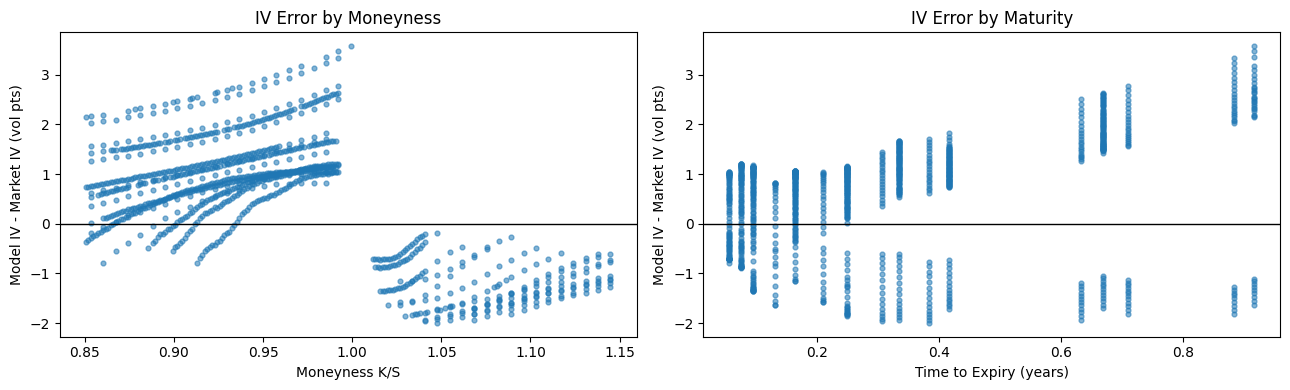

In [18]:
plot_data = fit.dropna(subset=["iv_error"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(plot_data["moneyness"], plot_data["iv_error"] * 100, s=12, alpha=0.55)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Moneyness K/S")
axes[0].set_ylabel("Model IV - Market IV (vol pts)")
axes[0].set_title("IV Error by Moneyness")

axes[1].scatter(plot_data["T"], plot_data["iv_error"] * 100, s=12, alpha=0.55)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Time to Expiry (years)")
axes[1].set_ylabel("Model IV - Market IV (vol pts)")
axes[1].set_title("IV Error by Maturity")

plt.tight_layout()
plt.show()

### Calibration Notes

The objective uses `loss_type="iv_proxy_rmse"`: Heston price error divided by Black-Scholes vega. This is a fast proxy for IV RMSE and avoids the double ATM tilt of dollar price RMSE plus vega weights.

The calibration dataset applies liquidity, spread, maturity, IV, and delta filters before optimization. The maturity window is 14 days to 1 year, because diagnostics showed that the long end was the main source of error. The calibration set is an in-memory DataFrame derived from the enriched options data; no separate calibration CSV is written.

All calibration metrics and diagnostics in this notebook are computed from the current `result` object and the current `calib` DataFrame.
